# Early-Stage Diabetes Risk Prediction

## 4. Baseline Model Building and Training

This notebook establishes the baseline performance of two classification models:

1. Random Forest
2. XGBoost

The models are trained using the preprocessed training data and evaluated on unseen test data. These baseline results will later be compared with the feature-selection and clustering approaches.

### 4.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

### 4.2 Load the Dataset

In [2]:
df = pd.read_csv("../data/diabetes_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100000, 31)


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


### 4.3 Prepare Features and Target

The target variable is `diagnosed_diabetes`:
- `0` = No Diabetes
- `1` = Diabetes

In [3]:
target_column = "diagnosed_diabetes"
leakage_columns = ["diabetes_stage"]

X = df.drop(columns=[target_column] + leakage_columns)
y = df[target_column].astype(int)

print("Target variable:", target_column)
print("Excluded leakage columns:", leakage_columns)
print("Input feature count:", X.shape[1])
print("Target classes:", sorted(y.unique()))

print("\nTarget distribution:")
display(y.value_counts().sort_index())

print("\nTarget percentage:")
display((y.value_counts(normalize=True).sort_index() * 100).round(3))

Target variable: diagnosed_diabetes
Excluded leakage columns: ['diabetes_stage']
Input feature count: 29
Target classes: [np.int64(0), np.int64(1)]

Target distribution:


diagnosed_diabetes
0    40002
1    59998
Name: count, dtype: int64


Target percentage:


diagnosed_diabetes
0    40.002
1    59.998
Name: proportion, dtype: float64

### 4.4 Train/Test Split

An 80/20 stratified split is used. Stratification keeps the proportion of the two target classes similar in the training and test sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(3))

print("\nTesting class distribution:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(3))

Training samples: 80000
Testing samples: 20000

Training class distribution:
diagnosed_diabetes
0    40.003
1    59.998
Name: proportion, dtype: float64

Testing class distribution:
diagnosed_diabetes
0    40.0
1    60.0
Name: proportion, dtype: float64


### 4.5 Build the Preprocessing Pipeline

In [5]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 23
Categorical features: 6


### 4.6 Transform Training and Test Data

The preprocessing transformer is fitted **only on the training data** and then applied to the test data. This prevents the test set from influencing the learned preprocessing parameters.

In [6]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (80000, 47)
Processed testing shape: (20000, 47)


### 4.7 Random Forest Baseline

In [7]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

rf_predictions = rf_model.predict(X_test_processed)
rf_probabilities = rf_model.predict_proba(X_test_processed)[:, 1]

print("Random Forest training completed.")

Random Forest training completed.


### 4.8 XGBoost Baseline

In [8]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(X_train_processed, y_train)

xgb_predictions = xgb_model.predict(X_test_processed)
xgb_probabilities = xgb_model.predict_proba(X_test_processed)[:, 1]

print("XGBoost training completed.")

XGBoost training completed.


### 4.9 Evaluation Function

In [9]:
def evaluate_model(model_name, y_true, predictions, probabilities):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1-Score": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities)
    }

    print(f"\n{model_name}")
    print("=" * len(model_name))
    print(classification_report(
        y_true,
        predictions,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0
    ))

    return results

In [10]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions,
    rf_probabilities
)

xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_predictions,
    xgb_probabilities
)


Random Forest
              precision    recall  f1-score   support

 No Diabetes       0.83      1.00      0.91      8000
    Diabetes       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000


XGBoost
              precision    recall  f1-score   support

 No Diabetes       0.83      1.00      0.91      8000
    Diabetes       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



### 4.10 Baseline Model Comparison

In [11]:
baseline_results = pd.DataFrame([rf_results, xgb_results])

baseline_results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9198,0.9994,0.8668,0.9284,0.9424
1,XGBoost,0.9193,0.9988,0.8666,0.9280,0.9423


**Observation:** This table provides the baseline performance of Random Forest and XGBoost. These results will be used as the reference point for the later feature-selection and clustering experiments.

### 4.11 Confusion Matrix — Random Forest

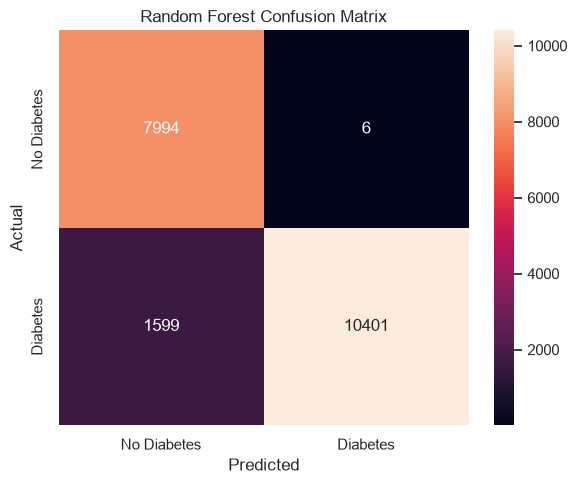

In [12]:
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 4.12 Confusion Matrix — XGBoost

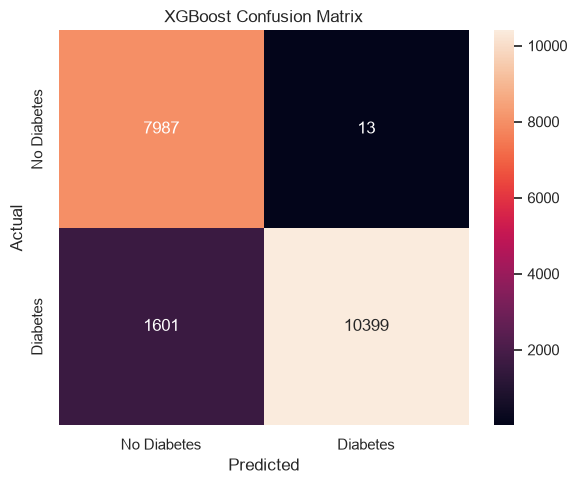

In [13]:
xgb_cm = confusion_matrix(y_test, xgb_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 4.13 ROC Curves

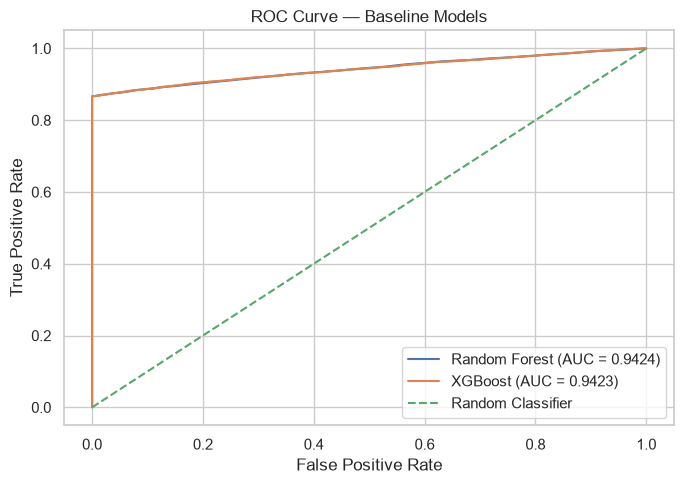

In [14]:
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probabilities)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probabilities)

plt.figure(figsize=(7, 5))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_results['ROC-AUC']:.4f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {xgb_results['ROC-AUC']:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve — Baseline Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

### 4.14 Baseline Findings

The baseline experiment provides the first comparison between Random Forest and XGBoost using the same training/testing split and preprocessing procedure. The model with stronger overall evaluation metrics will provide the baseline reference for the next stages.

**Important:** The final conclusion about the best model will be made only after the feature-selection, clustering, and tuning experiments are completed.

## Baseline Experiment Summary

**Models implemented:**
- Random Forest
- XGBoost

**Evaluation metrics:**
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- Classification Report

**Next stage:** XGBoost feature importance and feature selection.